In [2]:
!pip install scikit-learn pandas numpy matplotlib seaborn xgboost shap

  Using cached scikit_learn-1.9.1-cp312-cp312-win_amd64.whl.metadata (9.3 kB)
  Using cached xgboost-3.4.1-py3-none-win_amd64.whl.metadata (2.0 kB)
  Using cached shap-0.52.0-cp312-abi3-win_amd64.whl.metadata (26 kB)
  Using cached joblib-1.6.0-py3-none-any.whl.metadata (6.5 kB)
  Using cached threadpoolctl-3.7.0-py3-none-any.whl.metadata (24 kB)
  Using cached tqdm-4.70.1-py3-none-any.whl.metadata (57 kB)
  Using cached slicer-0.0.8-py3-none-any.whl.metadata (4.0 kB)
  Using cached numba-0.67.0-cp312-cp312-win_amd64.whl.metadata (2.8 kB)
  Using cached llvmlite-0.49.0-cp312-cp312-win_amd64.whl.metadata (5.2 kB)
  Using cached cloudpickle-3.1.2-py3-none-any.whl.metadata (7.1 kB)
Using cached scikit_learn-1.9.1-cp312-cp312-win_amd64.whl (8.3 MB)
Using cached xgboost-3.4.1-py3-none-win_amd64.whl (48.9 MB)
Using cached shap-0.52.0-cp312-abi3-win_amd64.whl (499 kB)
Using cached slicer-0.0.8-py3-none-any.whl (15 kB)
Using cached joblib-1.6.0-py3-none-any.whl (306 kB)
Using cached cloudpickl


[notice] A new release of pip is available: 25.0.1 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# 1. Carregando os dados via TensorFlow
url = "https://storage.googleapis.com/download.tensorflow.org/data/creditcard.csv"
df = pd.read_csv(url)

# 2. Mostrando o desbalanceamento
print(df['Class'].value_counts(normalize=True) * 100)

# 3. Preparando os dados
rob_scaler = RobustScaler()
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))
df.drop(['Time','Amount'], axis=1, inplace=True)

X = df.drop('Class', axis=1)
y = df['Class']

# Stratify é o segredo aqui para manter 0.17% de fraudes no treino e no teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"Treino: {X_train.shape[0]} linhas")

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64
Treino: 227845 linhas


--- REGRESSÃO LOGÍSTICA (BASELINE BALANCEADO) ---
              precision    recall  f1-score   support

           0       1.00      0.98      0.99     56864
           1       0.06      0.92      0.11        98

    accuracy                           0.98     56962
   macro avg       0.53      0.95      0.55     56962
weighted avg       1.00      0.98      0.99     56962



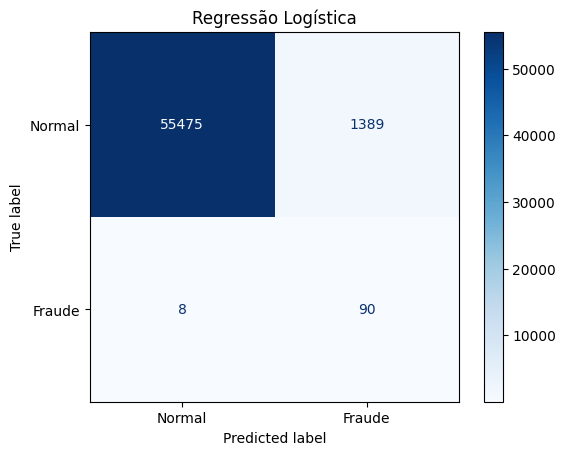

In [4]:
# CÉLULA 2: Regressão Logística com pesos balanceados
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

# Instanciando o modelo com pesos balanceados
modelo_rl = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
modelo_rl.fit(X_train, y_train)

# Previsões e Avaliação
y_pred_rl = modelo_rl.predict(X_test)

print("--- REGRESSÃO LOGÍSTICA (BASELINE BALANCEADO) ---")
print(classification_report(y_test, y_pred_rl))

# Matriz de Confusão
cm_rl = confusion_matrix(y_test, y_pred_rl)
disp_rl = ConfusionMatrixDisplay(confusion_matrix=cm_rl, display_labels=['Normal', 'Fraude'])
disp_rl.plot(cmap='Blues', values_format='d')
plt.title('Regressão Logística')
plt.show()

In [5]:
# CÉLULA 3: Random Forest e XGBoost
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# --- RANDOM FOREST ---
# max_depth=10 e n_estimators=50 para treinar rápido, mas manter bom desempenho
modelo_rf = RandomForestClassifier(class_weight='balanced', max_depth=10, n_estimators=50, random_state=42, n_jobs=-1)
modelo_rf.fit(X_train, y_train)
y_pred_rf = modelo_rf.predict(X_test)

print("--- RANDOM FOREST ---")
print(classification_report(y_test, y_pred_rf))

# --- XGBOOST ---
# scale_pos_weight = (total de negativos) / (total de positivos)
peso_xg = len(y_train[y_train == 0]) / len(y_train[y_train == 1])

modelo_xgb = XGBClassifier(scale_pos_weight=peso_xg, random_state=42, max_depth=5, learning_rate=0.1)
modelo_xgb.fit(X_train, y_train)
y_pred_xgb = modelo_xgb.predict(X_test)

print("\n--- XGBOOST ---")
print(classification_report(y_test, y_pred_xgb))

--- RANDOM FOREST ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.64      0.84      0.72        98

    accuracy                           1.00     56962
   macro avg       0.82      0.92      0.86     56962
weighted avg       1.00      1.00      1.00     56962


--- XGBOOST ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.50      0.85      0.63        98

    accuracy                           1.00     56962
   macro avg       0.75      0.92      0.81     56962
weighted avg       1.00      1.00      1.00     56962



--- XGBOOST COM LIMIAR DE 30.0% ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.36      0.87      0.51        98

    accuracy                           1.00     56962
   macro avg       0.68      0.93      0.75     56962
weighted avg       1.00      1.00      1.00     56962



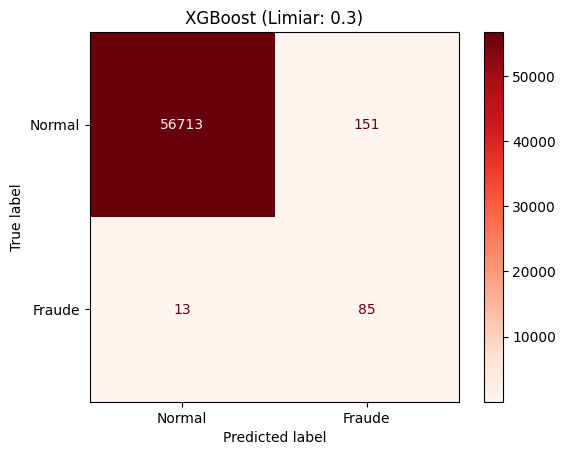

In [6]:
# CÉLULA 4: Ajuste do Limiar no XGBoost
# Pegamos as probabilidades (e não a decisão final) da classe 1 (Fraude)
probabilidades_xgb = modelo_xgb.predict_proba(X_test)[:, 1]

# Definimos um novo limiar (Threshold) de 30%
novo_limiar = 0.30

# Se a probabilidade for maior que 0.30, marcamos como fraude (1)
y_pred_ajustado = (probabilidades_xgb >= novo_limiar).astype(int)

print(f"--- XGBOOST COM LIMIAR DE {novo_limiar * 100}% ---")
print(classification_report(y_test, y_pred_ajustado))

cm_ajustada = confusion_matrix(y_test, y_pred_ajustado)
disp_ajustada = ConfusionMatrixDisplay(confusion_matrix=cm_ajustada, display_labels=['Normal', 'Fraude'])
disp_ajustada.plot(cmap='Reds', values_format='d')
plt.title(f'XGBoost (Limiar: {novo_limiar})')
plt.show()

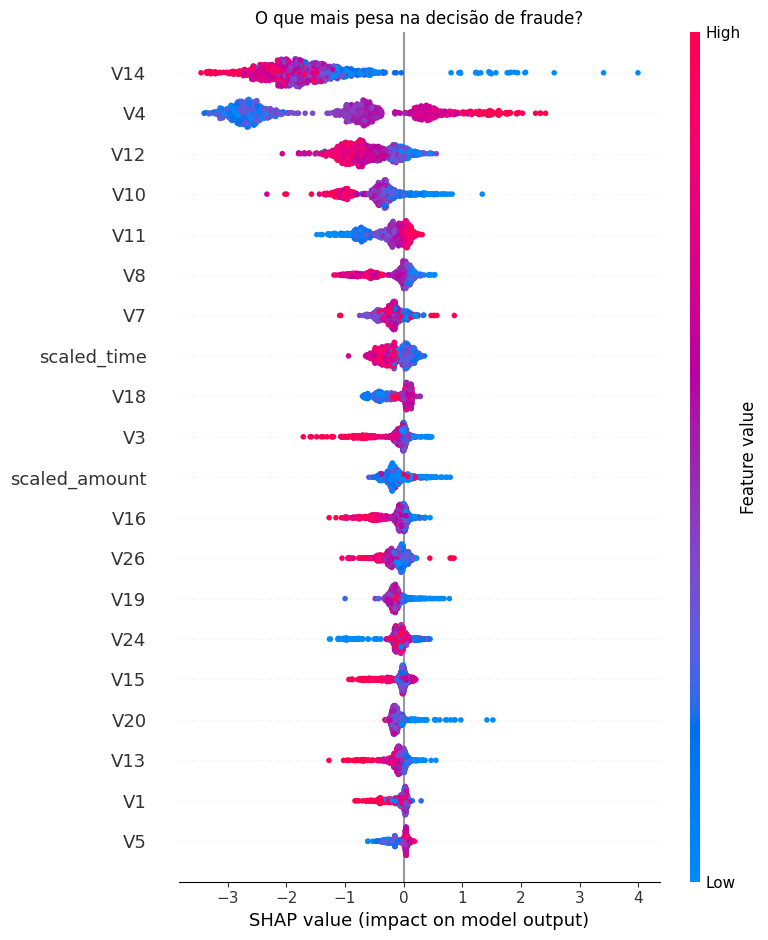

In [7]:
# CÉLULA 5: Explicando o modelo com SHAP
import shap

# Para não travar a memória do computador, usamos uma amostra de 1000 transações do teste
X_teste_amostra = X_test.sample(n=1000, random_state=42)

# Criamos o "Explicador" usando o nosso modelo XGBoost treinado
explainer = shap.TreeExplainer(modelo_xgb)
shap_values = explainer.shap_values(X_teste_amostra)

# Plotando o impacto das variáveis (Summary Plot)
plt.title("O que mais pesa na decisão de fraude?")
shap.summary_plot(shap_values, X_teste_amostra)